Incisos 9 al 13 del laboratorio 9

In [63]:
#librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import learning_curve,train_test_split,  RandomizedSearchCV
from sklearn.pipeline import Pipeline


Se importan los datos

In [25]:
df = pd.read_csv('datos_limpios.csv')
df.head(5)

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,room_type_Hotel room,room_type_Private room,room_type_Shared room,calendar_last_scraped_2025-09-16,calendar_last_scraped_2025-09-17,calendar_last_scraped_2025-09-22,calendar_last_scraped_2025-09-23,calendar_last_scraped_2025-09-24,calendar_last_scraped_2025-09-25,calendar_last_scraped_2025-09-30
0,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,2.0,97.0,2,...,0,0,0,0,1,0,0,0,0,0
1,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,2.0,160.0,3,...,0,0,0,0,1,0,0,0,0,0
2,1.0,1.0,30.23466,-97.73682,2,1.0,1.0,1.0,38.0,4,...,0,0,0,0,1,0,0,0,0,0
3,2.0,2.0,30.26098,-97.73072,3,2.0,2.0,2.0,145.0,15,...,0,0,0,0,1,0,0,0,0,0
4,1.0,1.0,30.23614,-97.73225,2,1.0,1.0,1.0,58.0,30,...,0,0,0,1,0,0,0,0,0,0


In [26]:
df = df.fillna(df.median(numeric_only=True))

In [27]:
#Esto es parte del INCISO 9
#Se procede a la separación de las variables de esta manera,
#dado que se ha de hacer la regresión directamente respecto al precio
y = df["price"]

#Variables predictoras
X = df.drop(columns=["price"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
columnas=X_train.columns
scaler = MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [29]:
X_train=pd.DataFrame(X_train, columns=columnas)
X_test=pd.DataFrame(X_test, columns=columnas)

In [30]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 3 * IQR
sup = Q3 + 3 * IQR

INCISO 10: MODELOS DE REGRESIÓN CON REDES NEURONALES

In [31]:
modelo1 = MLPRegressor(
    hidden_layer_sizes=(10,),
    activation='relu',
    max_iter=1000
)

In [32]:
modelo1.fit(X_train, y_train)

C:\Users\aripi\anaconda3\envs\DataMining\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [33]:
y_pred1=modelo1.predict(X_test)

In [34]:
modelo2 = MLPRegressor(
    hidden_layer_sizes=(20,10),
    activation='tanh',
    max_iter=1000
)

In [35]:
modelo2.fit(X_train, y_train)

C:\Users\aripi\anaconda3\envs\DataMining\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [36]:
y_pred2=modelo2.predict(X_test)

INCISO 11: COMPARACIÓN DE MODELOS DE REGRESIÓN

In [37]:
def comparacion_metricas(y1, y2, y_true):
    MSE=[]
    RMSE=[]
    R2=[]
    #MSE
    ms1=mean_squared_error(y_true, y1)
    ms2=mean_squared_error(y_true, y2)
    MSE.append(ms1)
    MSE.append(ms2)
    #RMSE
    rmse1=root_mean_squared_error(y_true, y1)
    rmse2=root_mean_squared_error(y_true, y2)
    RMSE.append(rmse1)
    RMSE.append(rmse2)
    #R2
    r21=r2_score(y_true, y1)
    r22=r2_score(y_true, y2)
    R2.append(r21)
    R2.append(r22)

    metrics=pd.DataFrame({
        "Modelo": ["modelo 1","modelo 2"],
        "MSE": MSE,
        "RMSE": RMSE,
        "R2":R2
    })
    return metrics

In [38]:
comparacion_metricas(y_pred1,y_pred2,y_test)

,Modelo,MSE,RMSE,R2
0,modelo 1,8.085643e+06,2843.526488,0.563685
1,modelo 2,1.650496e+07,4062.629352,0.109364


Se observa que de los dos modelos, el primer modelo presenta menores valores de MSE y RMSE, así como un mayor $R^2$ en comparación al segundo modelo.
Es así como se determina que de ambos, es el modelo 1 el mejor.

INCISO 12: ANÁLISIS DE SOBREAJUSTE POR MEDIO DE CURVA DE APRENDIZAJE.

In [49]:
def LearningCurve(model, X, y, titulo):
    
    train_sizes, train_scores, val_scores = learning_curve(model,X,y,cv=3,scoring="neg_mean_squared_error",train_sizes=np.linspace(0.3, 0.6, 3),n_jobs=-1)
    
    # Convertir a RMSE
    train_scores = np.sqrt(-train_scores)
    val_scores = np.sqrt(-val_scores)
    
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    
    # 🔹 Gráfica
    plt.figure(figsize=(7,5))
    
    plt.plot(train_sizes, train_mean, 'o-', label="Train")
    plt.plot(train_sizes, val_mean, 'o-', label="Validation")
    
    plt.xlabel("Tamaño del dataset")
    plt.ylabel("RMSE")
    plt.title(titulo)
    
    plt.legend()
    plt.grid(True)
    plt.show()

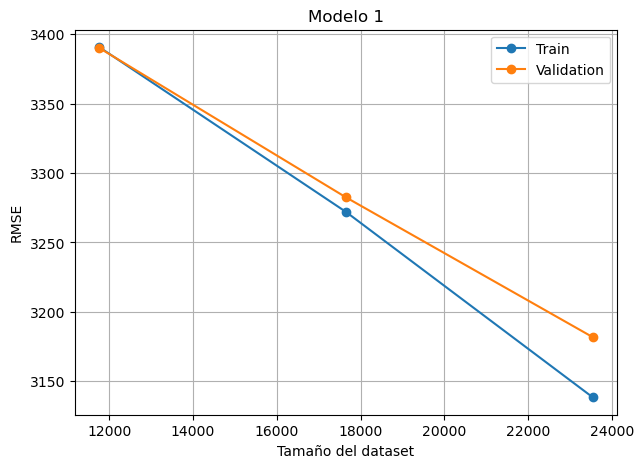

In [50]:
LearningCurve(modelo1, X_train, y_train, "Modelo 1")

Se observa que la tendencia del primer modelo es decreciente. Este inicia con cierto subajuste y decrece conforme el tamaño del conjunto de datos incrementa. La diferencia entre los resultados del conjunto Train y el Validation es relativamente pequeña, dado que ambas líneas están cercanas gráficamente entre sí; es posible ver que el modelo generaliza más en el Validation set. Dado que el RMSE se reduce conforme la información aumenta y que Train y Validation son cercanos, puede considerarse que el modelo tenderá al sobreajuste conforme aumente la información.

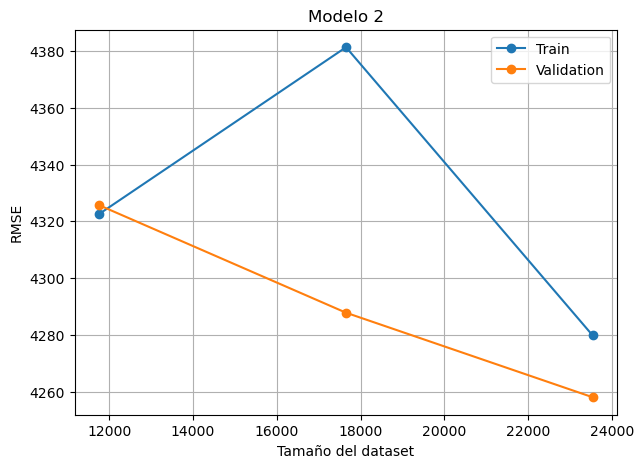

In [51]:
LearningCurve(modelo2, X_train, y_train, "Modelo 2")

Se observa que la diferencia entre el Train y Validation set es visiblemente grande; el Validation set tiene menor error que el Train set. Asimismo, ambos modelos tienden al sobreajuste conforme aumenta la información, aunque los modelos no empiezan desde el sobreajuste. No obstante, el Train set tiende a sobreajustarse en datos cercanos a 180000.

INCISO 13: AJUSTE DEL MEJOR MODELO (MODELO I)

In [55]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", modelo1)
])

In [56]:
param_dist = {
    "mlp__hidden_layer_sizes": [(50,), (100,), (50,50)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [0.0001, 0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.01]
}

In [59]:
search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=10,  
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'mlp__activation': ['relu', 'tanh'], 'mlp__alpha': [0.0001, 0.001, ...], 'mlp__hidden_layer_sizes': [(50,), (100,), ...], 'mlp__learning_rate_init': [0.001, 0.01]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscr

In [60]:
print("Mejores parámetros:")
print(search.best_params_)

Mejores parámetros:
{'mlp__learning_rate_init': 0.01, 'mlp__hidden_layer_sizes': (50, 50), 'mlp__alpha': 0.01, 'mlp__activation': 'relu'}


In [64]:
mse = mean_squared_error(y_test, y_pred1)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred1)
r2 = r2_score(y_test, y_pred1)

print("\n=== Métricas ===")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


=== Métricas ===
RMSE: 2843.526488416564
MAE: 776.6041796289754
R2: 0.5636845203071426


Se puede observar que los errores RMSE y MAE se redujeron considerablemente respecto al modelo original del MODELO 1. $R^2$ ha mantenido su valor anterior de 0.56. Aún así, puede decirse que este modelo tiene características de sobreajuste, puesto que el error se ha reducido drásticamente, lo que está en concordancia con la línea de aprendizaje mostrada en el inciso anterior.